In [ ]:
# Naive Bayes Algorithm

In [ ]:
# P(e) = F.O./T.O. ----> 0 <= P(e) <= 1

In [ ]:
# 1. Independent
# 2. Dependent

In [ ]:
# P(A n B) = P(B/A) P(A)
# P(B n A) = P(A/B) P(B)

In [ ]:
# P(A|B) = (P(B|A) P(A))/P(B)

In [ ]:
# types of naive bayes = 1. Gaussian 2. Multinomial 3. Bernoulli

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [9]:
dataset = pd.read_csv("placements.csv")
dataset.head(3)

,cgpa,score,placement
0,6.8,6.15,1
1,5.9,5.30,0
2,5.3,6.05,0


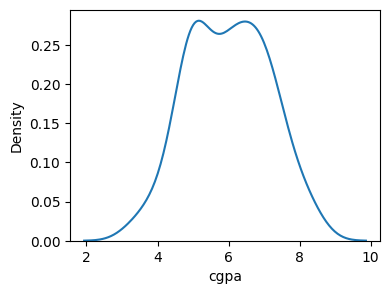

In [22]:
plt.figure(figsize=(4, 3))
sns.kdeplot(data=dataset["cgpa"])
plt.show()

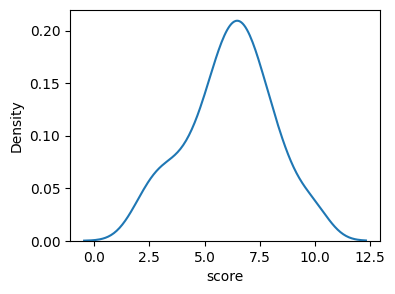

In [23]:
plt.figure(figsize=(4, 3))
sns.kdeplot(data=dataset["score"])
plt.show()

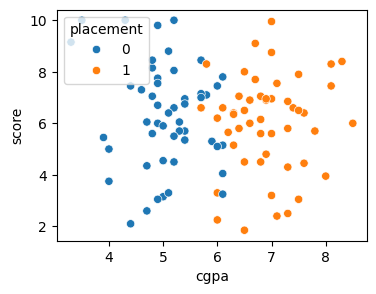

In [15]:
plt.figure(figsize=(4, 3))
sns.scatterplot(x="cgpa", y="score", data=dataset, hue="placement")
plt.show()

In [16]:
dataset["placement"].value_counts()

placement
1    50
0    50
Name: count, dtype: int64

In [17]:
x = dataset.iloc[:,:-1]
x

,cgpa,score
0,6.8,6.15
1,5.9,5.30
2,5.3,6.05
3,7.4,6.60
4,5.8,7.10
...,...,...
95,4.3,10.00
96,4.4,2.10
97,6.7,9.10
98,6.3,5.15


In [18]:
y = dataset["placement"]
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [35]:
from mlxtend.plotting import plot_decision_regions

In [24]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [25]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [26]:
gnb.score(x_test, y_test)*100

85.0

In [27]:
gnb.score(x_train, y_train)*100

91.25

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


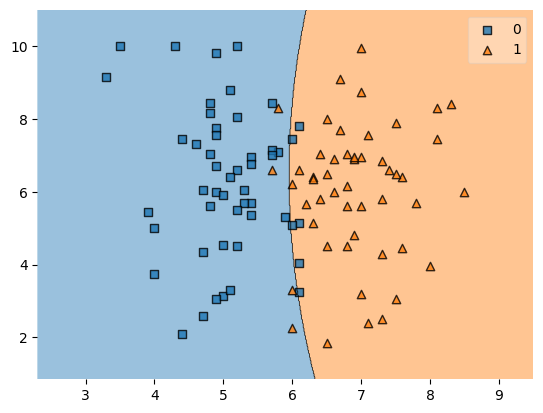

In [36]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=gnb)
plt.show()

In [28]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [29]:
mnb.score(x_test, y_test)*100

95.0

In [31]:
mnb.score(x_train, y_train)*100

70.0

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


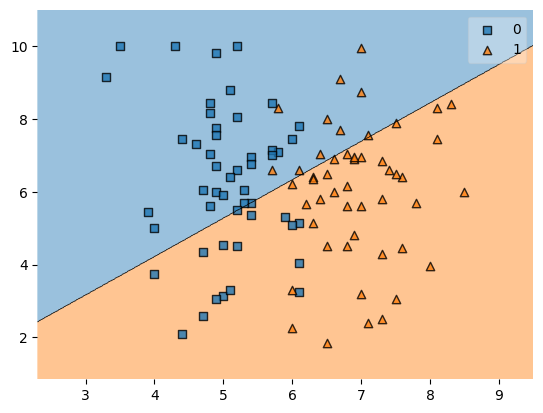

In [37]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=mnb)
plt.show()

In [32]:
bnb = BernoulliNB()
bnb.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [34]:
bnb.score(x_test, y_test)*100

50.0

In [33]:
bnb.score(x_train, y_train)*100

50.0

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


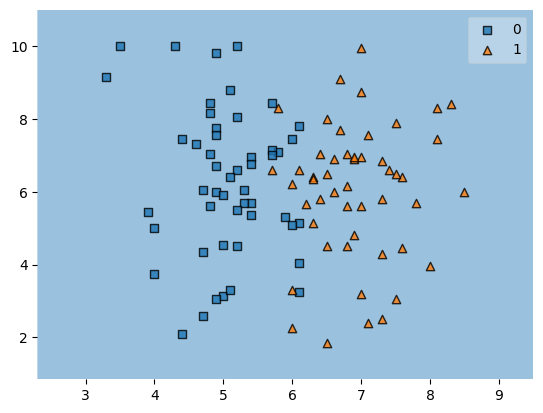

In [38]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=bnb)
plt.show()

In [39]:
gnb.predict([[8.14, 6.52]])

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

In [40]:
mnb.predict([[8.14, 6.52]])

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


array([1])

In [41]:
bnb.predict([[8.14, 6.52]])

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


array([0])